In [183]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("group_20_1.csv")

target = "Amyl"

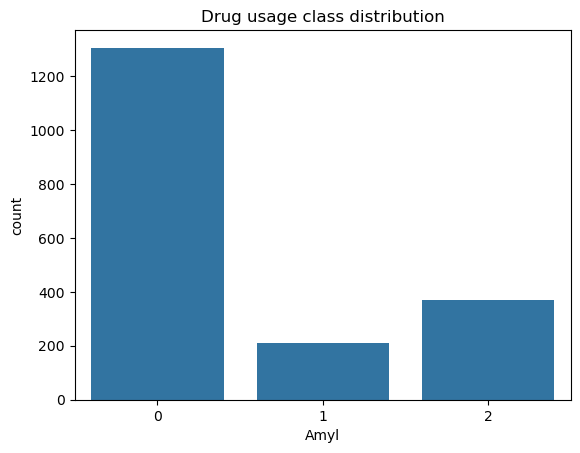

In [2]:
sns.countplot(x=target, data=df)
plt.title("Drug usage class distribution")
plt.show()

In [ ]:
features = [
"Nscore","Escore","Oscore","Ascore","Cscore",
"Impulsive","SS","Age","Gender","Education","Amyl"
]

for col in features:
    
    plt.figure(figsize=(6,4))
    sns.boxplot(x=target, y=col, data=df)
    
    plt.title(f"{col} vs Drug Use")
    plt.show()

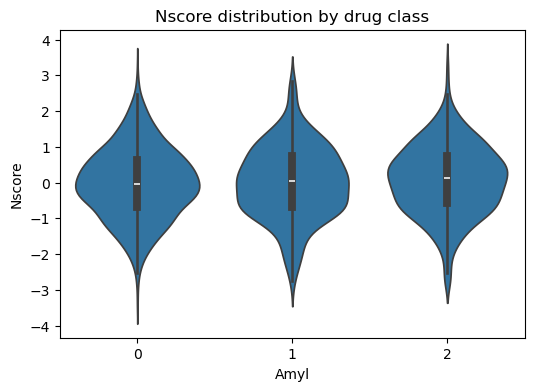

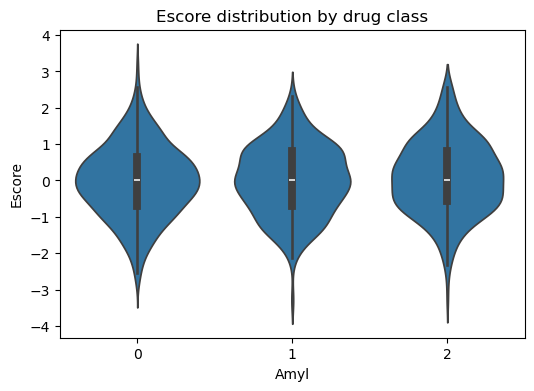

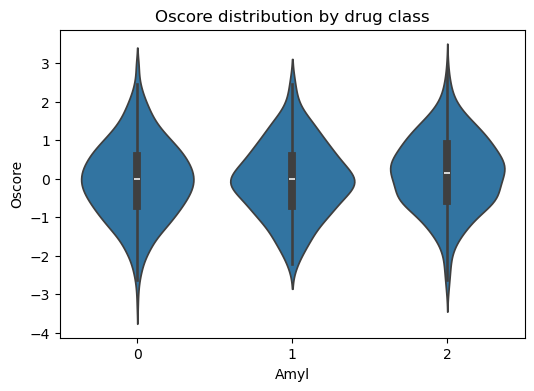

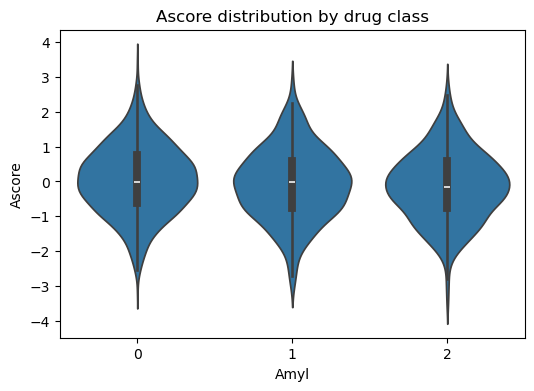

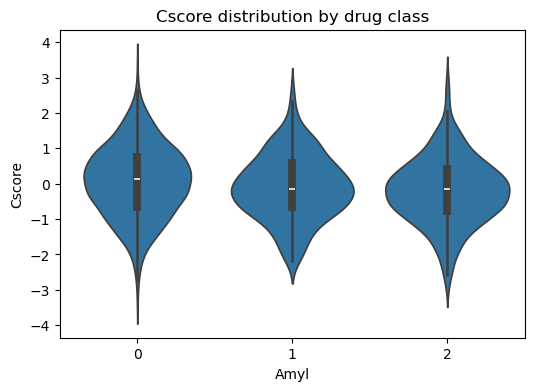

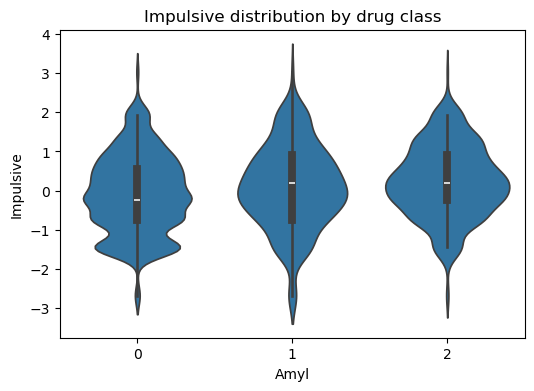

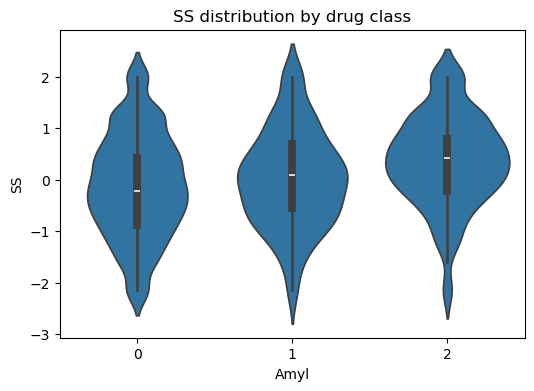

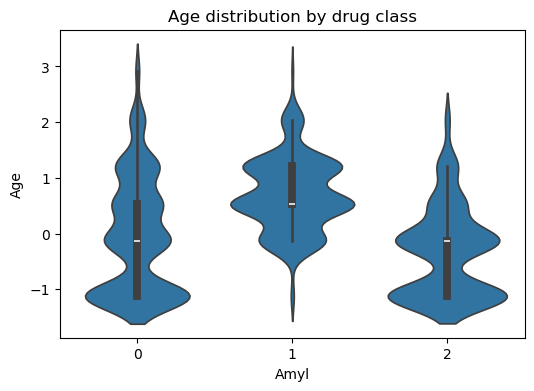

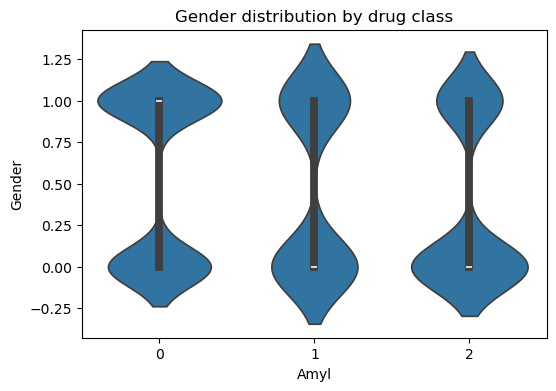

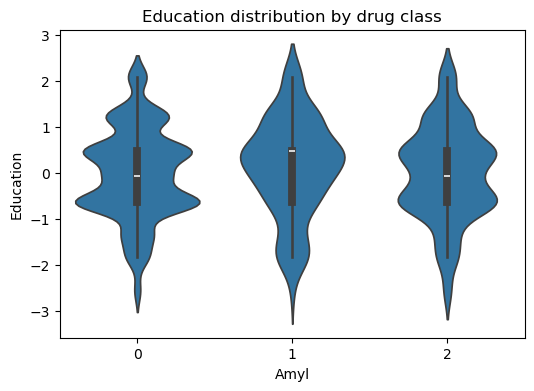

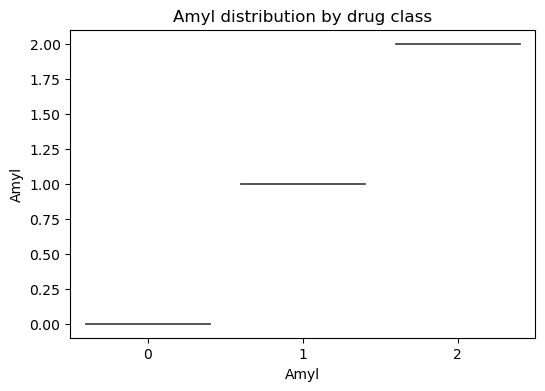

In [185]:
for col in features:

    plt.figure(figsize=(6,4))
    
    sns.violinplot(x=target, y=col, data=df)
    
    plt.title(f"{col} distribution by drug class")
    
    plt.show()

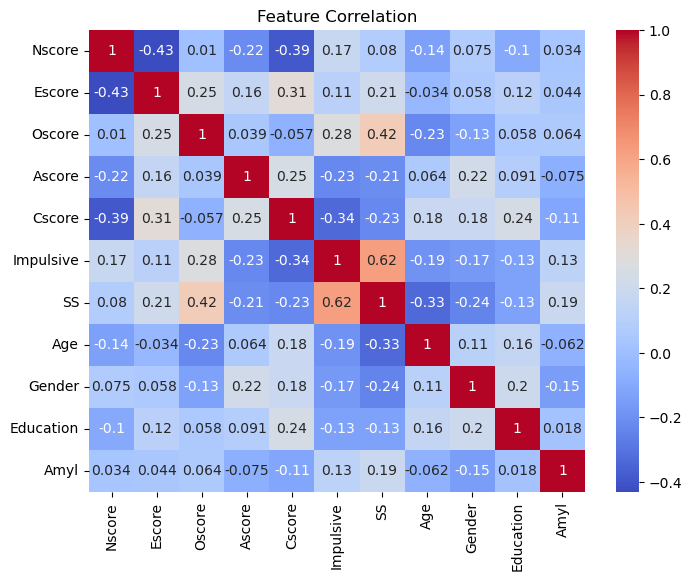

In [186]:
corr = df[features].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True
)

plt.title("Feature Correlation")
plt.show()

In [187]:
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [ ]:
#重采样函数，目前仅支持pd.Dataframe格式输入输出
def resample_pytorch(df, target_row, n_samples=200,seed=43):
    balanced_data = []
    torch.manual_seed(seed)
    for c in df[target_row].unique():
        subset = df[df[target_row] == c]
        indices = torch.randint(0, len(subset), (n_samples,) )
        resampled = subset.iloc[indices.numpy()]
        balanced_data.append(resampled)
    
    return pd.concat(balanced_data)

In [ ]:
#测试
# temp=resample_pytorch(df,"Amyl")
# len(set(temp[temp.iloc[:,13]==0]["ID"]))
# df[df.iloc[:,13]==1]

177

In [ ]:
#存在数据泄露问题，要改
df_resample=resample_pytorch(df,"Amyl")
X=df_resample.iloc[:,1:12]
X.iloc[:,3:5]=df_resample.iloc[:,14:16].copy()
X=X.values
y=df_resample.iloc[:,13].values
n_features=X.shape[-1]
X

array([[ 0.52756593,  1.        , -0.05833058, ..., -0.91934136,
        -0.00628115, -0.23510842],
       [-0.1288537 ,  0.        ,  2.09319986, ...,  0.76336078,
        -0.14277542, -0.75297646],
       [ 0.52756593,  0.        , -0.05833058, ..., -1.62524491,
        -1.01690228, -1.45365042],
       ...,
       [-0.1288537 ,  1.        ,  0.48270524, ..., -1.77677285,
        -1.38844104,  0.54762541],
       [-1.12350447,  1.        , -0.6394053 , ..., -1.62524491,
        -2.57977769,  1.34669787],
       [-1.12350447,  0.        , -0.6394053 , ...,  1.1174608 ,
         0.41747077,  0.91587828]], shape=(1885, 11))

In [342]:
print(X.shape)
print(np.unique(y, return_counts=True))

(1885, 11)
(array([0, 1, 2]), array([1305,  210,  370]))


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
    test_size=0.3,
    random_state=42,
    stratify=y)
type(X_test)


numpy.ndarray

In [192]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [252]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)
print(X_train.shape,y_train.shape,X_test.shape)

torch.Size([420, 11]) torch.Size([420]) torch.Size([180, 11])


C:\Users\29583\AppData\Local\Temp\ipykernel_9400\2532761477.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype=torch.float32)
C:\Users\29583\AppData\Local\Temp\ipykernel_9400\2532761477.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test, dtype=torch.float32)
C:\Users\29583\AppData\Local\Temp\ipykernel_9400\2532761477.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.long)
C:\Users\29583\AppData\Local\Temp\ipykernel_9400\25327

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=64,shuffle=False)

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 3)   
        )
    def forward(self, x):
        return self.net(x)

In [335]:
model=Net()
criterion = nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.005)

In [ ]:
from collections import deque
epochs = 200
pre_loss=deque(maxlen=5)
pre=0
for epoch in range(epochs):

    model.train()

    total_loss = 0

    for X_batch, y_batch in train_loader:
        

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)
        loss.backward()

        optimizer.step()
        total_loss += loss.item()
    pre_loss.append(abs(pre-total_loss))
    pre=total_loss
    #早停判断
    if sum(pre_loss)<0.2:
        break
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")
print(pre_loss)

Epoch 1, Loss: 7.4520
Epoch 2, Loss: 6.7759
Epoch 3, Loss: 6.4192
Epoch 4, Loss: 5.9825
Epoch 5, Loss: 5.6226
Epoch 6, Loss: 5.3918
Epoch 7, Loss: 5.0565
Epoch 8, Loss: 5.0189
Epoch 9, Loss: 4.7971
Epoch 10, Loss: 4.6315
Epoch 11, Loss: 4.6192
Epoch 12, Loss: 4.4035
Epoch 13, Loss: 4.1709
Epoch 14, Loss: 3.9746
Epoch 15, Loss: 3.9710
Epoch 16, Loss: 3.8217
Epoch 17, Loss: 3.7755
Epoch 18, Loss: 3.4792
Epoch 19, Loss: 3.3668
Epoch 20, Loss: 3.2443
Epoch 21, Loss: 3.1745
Epoch 22, Loss: 3.0751
Epoch 23, Loss: 2.9527
Epoch 24, Loss: 2.9830
Epoch 25, Loss: 2.8901
Epoch 26, Loss: 2.7012
Epoch 27, Loss: 2.5944
Epoch 28, Loss: 2.4825
Epoch 29, Loss: 2.4246
Epoch 30, Loss: 2.3802
Epoch 31, Loss: 2.3310
Epoch 32, Loss: 2.2707
Epoch 33, Loss: 2.1475
Epoch 34, Loss: 2.0951
Epoch 35, Loss: 2.0968
Epoch 36, Loss: 1.8996
Epoch 37, Loss: 1.9279
Epoch 38, Loss: 1.8799
Epoch 39, Loss: 1.7689
Epoch 40, Loss: 1.6562
Epoch 41, Loss: 1.4822
Epoch 42, Loss: 1.7090
Epoch 43, Loss: 1.5767
Epoch 44, Loss: 1.39

In [337]:
model.eval()

preds = []
true = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)

        _, predicted = torch.max(outputs, 1)

        preds.extend(predicted.cpu().numpy())
        true.extend(y_batch.numpy())
ans=[0,0,0]
for x in preds:
    ans[x]+=1
ans

[45, 79, 56]

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(true, preds)

print("Test Accuracy:", acc)